In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_wine, make_blobs
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"Dataset shape: {X.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"Number of classes: {len(target_names)}")
print(f"Feature names:\n{feature_names}")
print(f"\nClass distribution:")
print(f"Class 0 ({target_names[0]}): {sum(y==0)} samples")
print(f"Class 1 ({target_names[1]}): {sum(y==1)} samples")

# Create DataFrame for visualization
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['target_name'] = df['target'].map({0: target_names[0], 1: target_names[1]})

Dataset shape: (569, 30)
Number of features: 30
Number of classes: 2
Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Class distribution:
Class 0 (malignant): 212 samples
Class 1 (benign): 357 samples


In [17]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0,malignant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0,malignant
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0,malignant
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0,malignant
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0,malignant


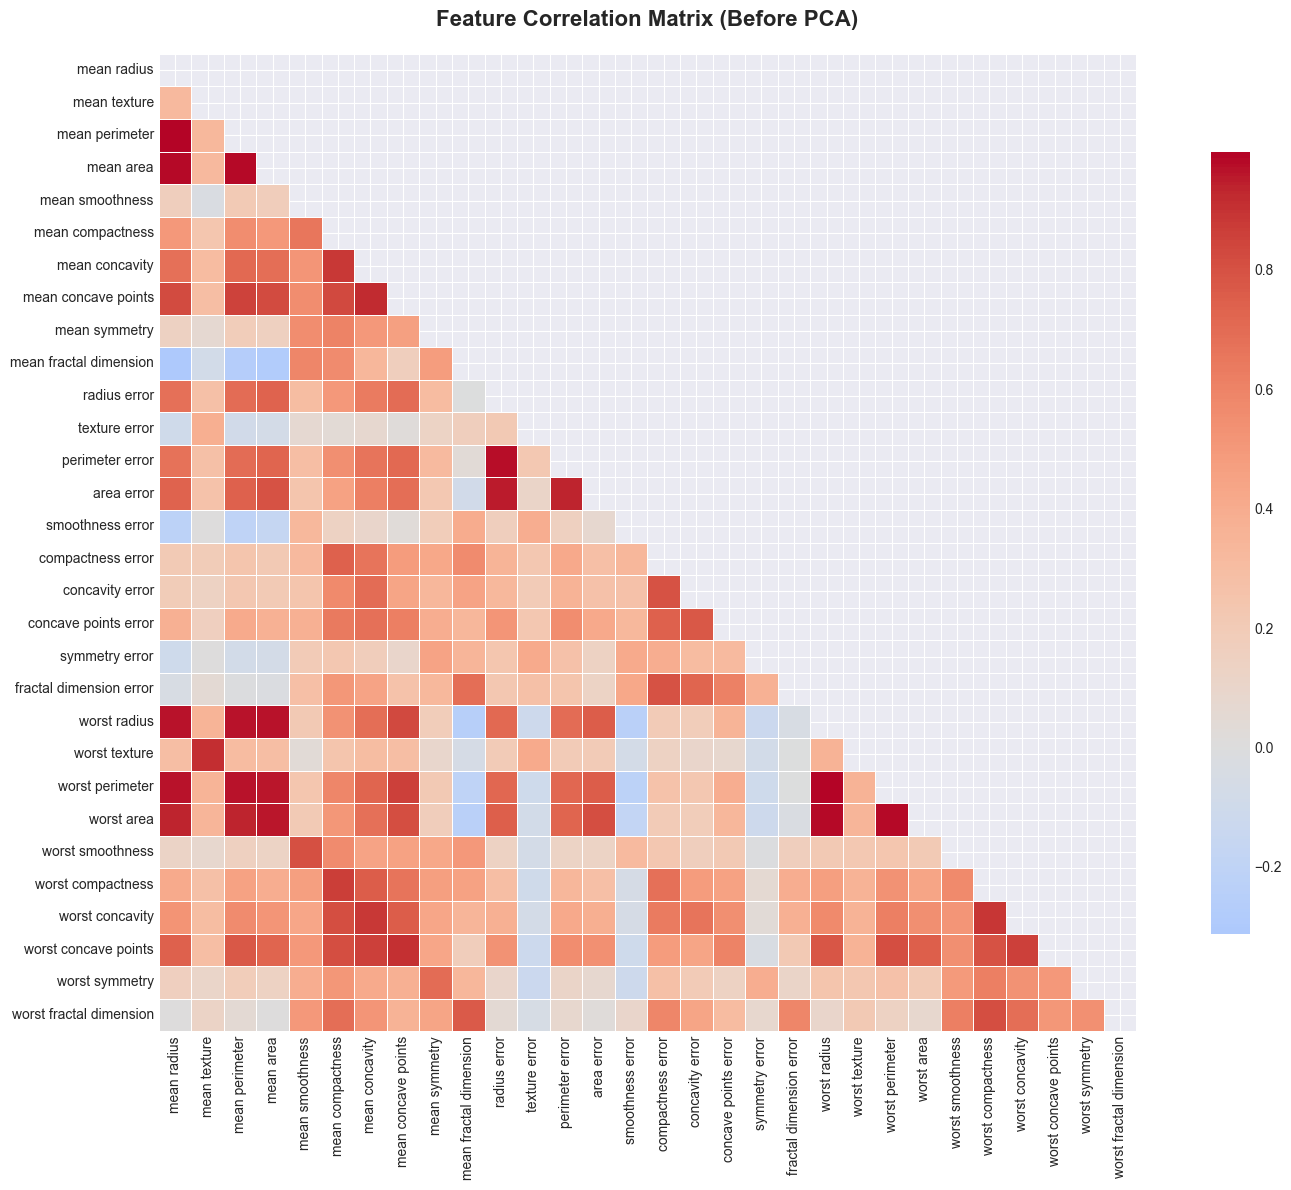


Highly correlated feature pairs (|r| > 0.8):
mean radius - mean perimeter: 0.998
mean radius - mean area: 0.987
mean radius - mean concave points: 0.823
mean radius - worst radius: 0.970
mean radius - worst perimeter: 0.965
mean radius - worst area: 0.941
mean texture - worst texture: 0.912
mean perimeter - mean area: 0.987
mean perimeter - mean concave points: 0.851
mean perimeter - worst radius: 0.969


In [3]:
plt.figure(figsize=(16, 12))

# Calculate correlation matrix
corr_matrix = df.iloc[:, :-2].corr()

# Plot heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title('Feature Correlation Matrix (Before PCA)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_before_pca.png', dpi=120, bbox_inches='tight')
plt.show()

# Check for high correlations
high_corr = np.where(np.abs(corr_matrix) > 0.8)
high_corr_pairs = [(corr_matrix.index[x], corr_matrix.columns[y], corr_matrix.iloc[x, y]) 
                   for x, y in zip(*high_corr) if x != y and x < y]

print(f"\nHighly correlated feature pairs (|r| > 0.8):")
for pair in high_corr_pairs[:10]:  # Show first 10
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.3f}")

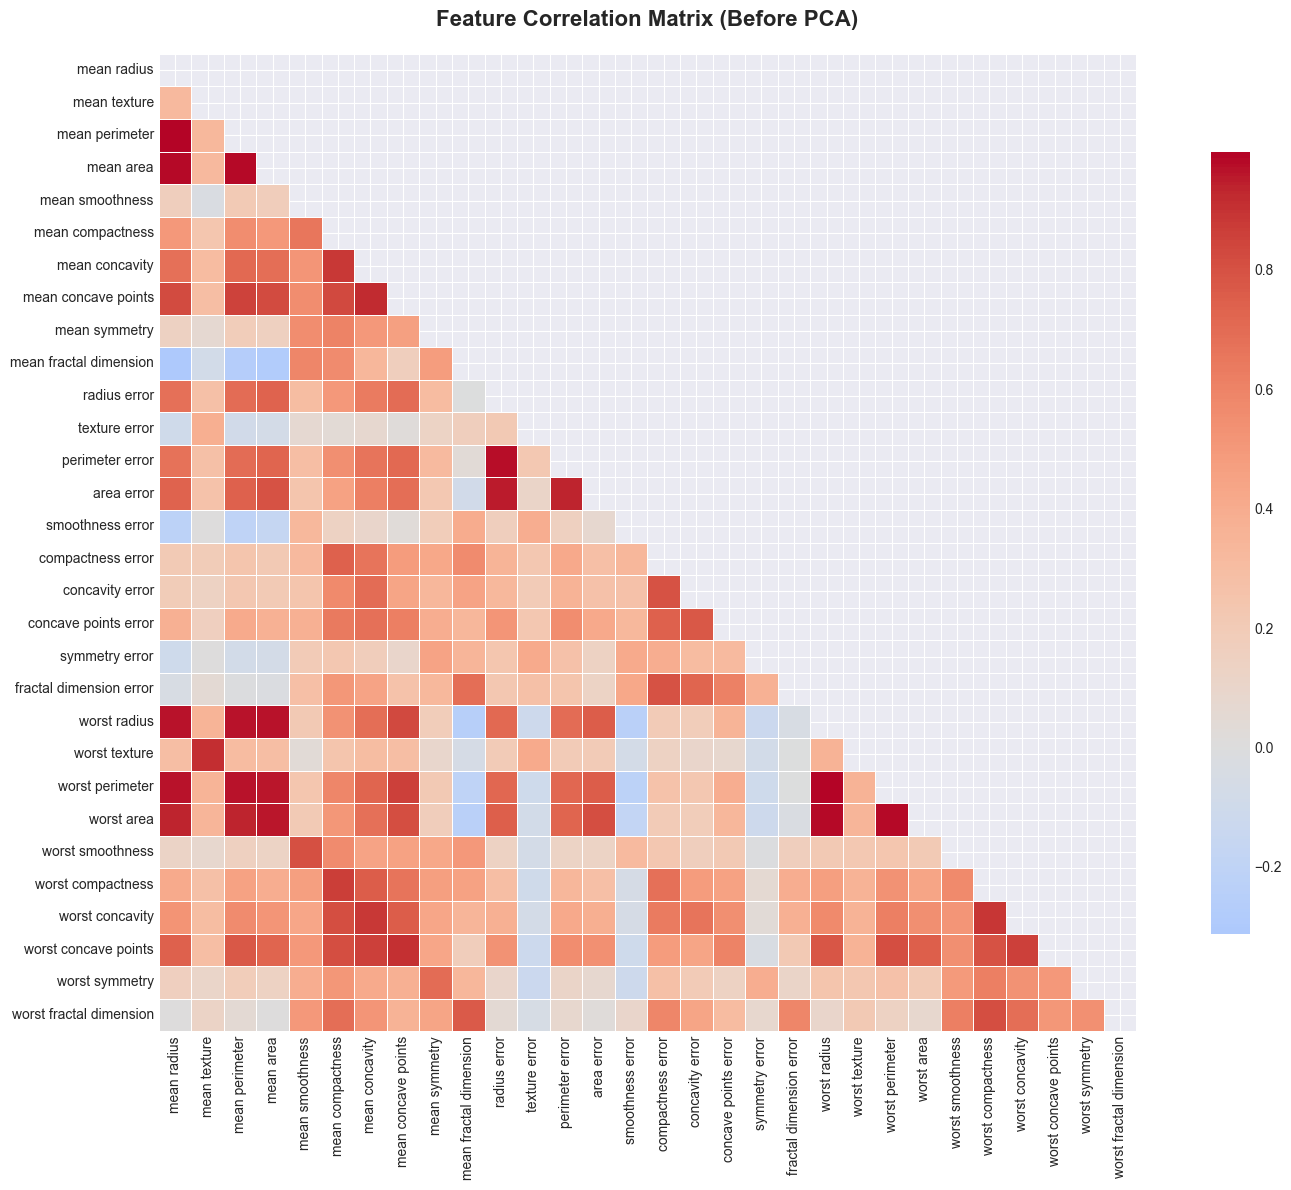


Highly correlated feature pairs (|r| > 0.8):
mean radius - mean perimeter: 0.998
mean radius - mean area: 0.987
mean radius - mean concave points: 0.823
mean radius - worst radius: 0.970
mean radius - worst perimeter: 0.965
mean radius - worst area: 0.941
mean texture - worst texture: 0.912
mean perimeter - mean area: 0.987
mean perimeter - mean concave points: 0.851
mean perimeter - worst radius: 0.969


In [4]:
plt.figure(figsize=(16, 12))

# Calculate correlation matrix
corr_matrix = df.iloc[:, :-2].corr()

# Plot heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title('Feature Correlation Matrix (Before PCA)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_before_pca.png', dpi=120, bbox_inches='tight')
plt.show()

# Check for high correlations
high_corr = np.where(np.abs(corr_matrix) > 0.8)
high_corr_pairs = [(corr_matrix.index[x], corr_matrix.columns[y], corr_matrix.iloc[x, y]) 
                   for x, y in zip(*high_corr) if x != y and x < y]

print(f"\nHighly correlated feature pairs (|r| > 0.8):")
for pair in high_corr_pairs[:10]:  # Show first 10
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.3f}")

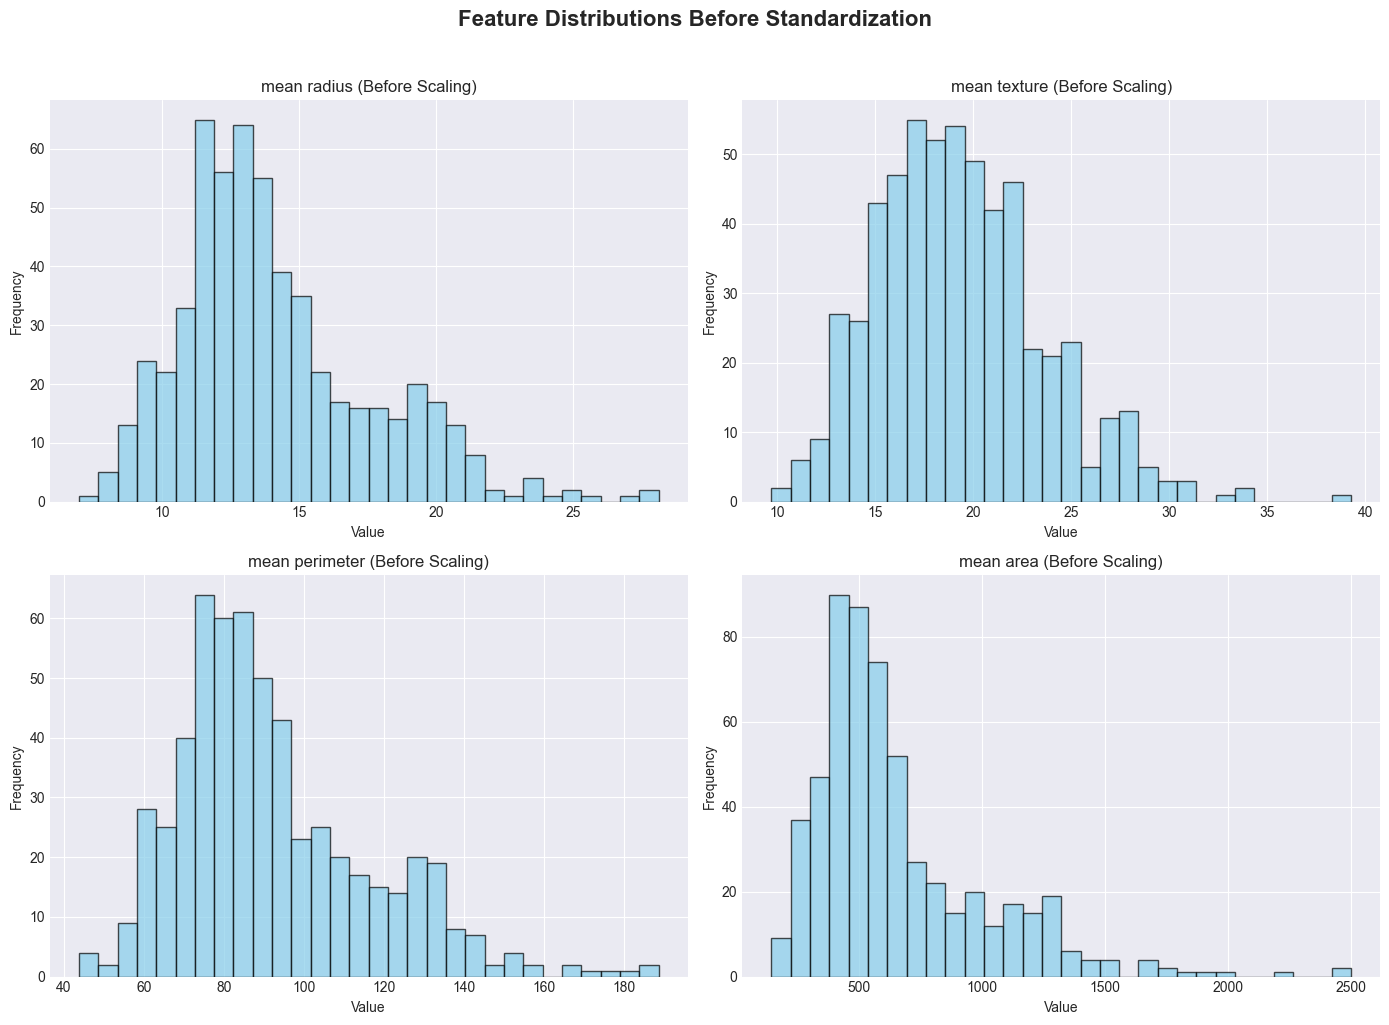

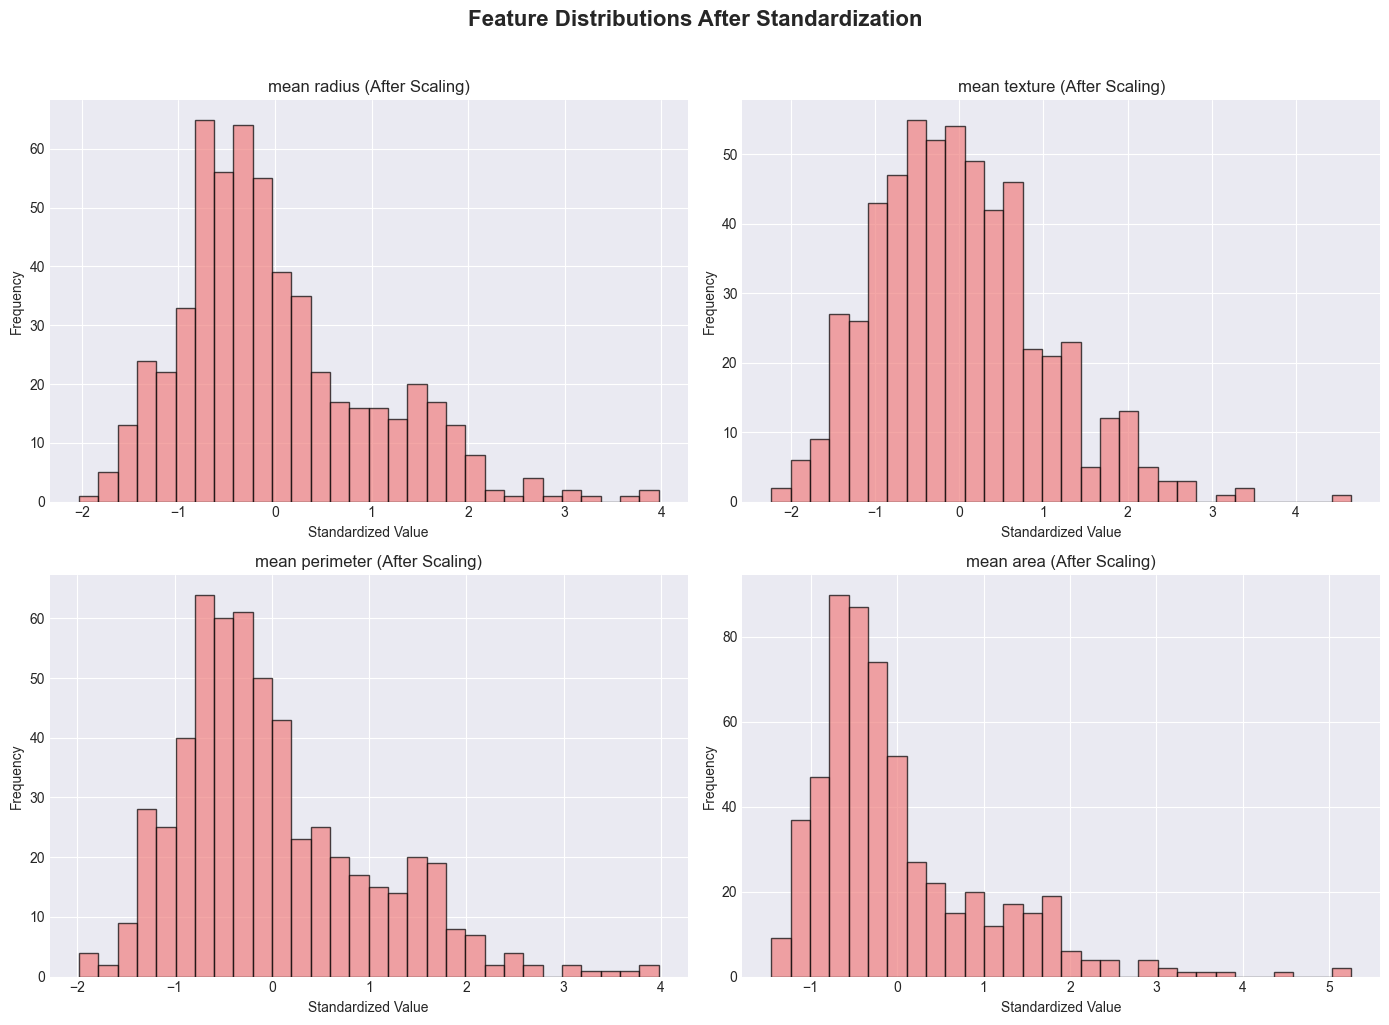

In [5]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Plot feature distributions before/after scaling
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Before scaling
for i, idx in enumerate([0, 1, 2, 3]):  # Plot first 4 features
    ax = axes[i//2, i%2]
    ax.hist(X[:, idx], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax.set_title(f'{feature_names[idx]} (Before Scaling)', fontsize=12)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.suptitle('Feature Distributions Before Standardization', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions_before_scaling.png', dpi=120, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# After scaling
for i, idx in enumerate([0, 1, 2, 3]):
    ax = axes[i//2, i%2]
    ax.hist(X_scaled[:, idx], bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
    ax.set_title(f'{feature_names[idx]} (After Scaling)', fontsize=12)
    ax.set_xlabel('Standardized Value')
    ax.set_ylabel('Frequency')

plt.suptitle('Feature Distributions After Standardization', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions_after_scaling.png', dpi=120, bbox_inches='tight')
plt.show()

In [6]:
# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Get explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Create components DataFrame
components_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Explained Variance': explained_variance,
    'Cumulative Variance': cumulative_variance
})

print("PCA Components Explained Variance:")
print(components_df.head(10).to_string(index=False))

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nNumber of components for 95% variance: {n_components_95}")
print(f"Variance with {n_components_95} components: {cumulative_variance[n_components_95-1]:.3%}")

PCA Components Explained Variance:
Component  Explained Variance  Cumulative Variance
      PC1            0.442720             0.442720
      PC2            0.189712             0.632432
      PC3            0.093932             0.726364
      PC4            0.066021             0.792385
      PC5            0.054958             0.847343
      PC6            0.040245             0.887588
      PC7            0.022507             0.910095
      PC8            0.015887             0.925983
      PC9            0.013896             0.939879
     PC10            0.011690             0.951569

Number of components for 95% variance: 10
Variance with 10 components: 95.157%


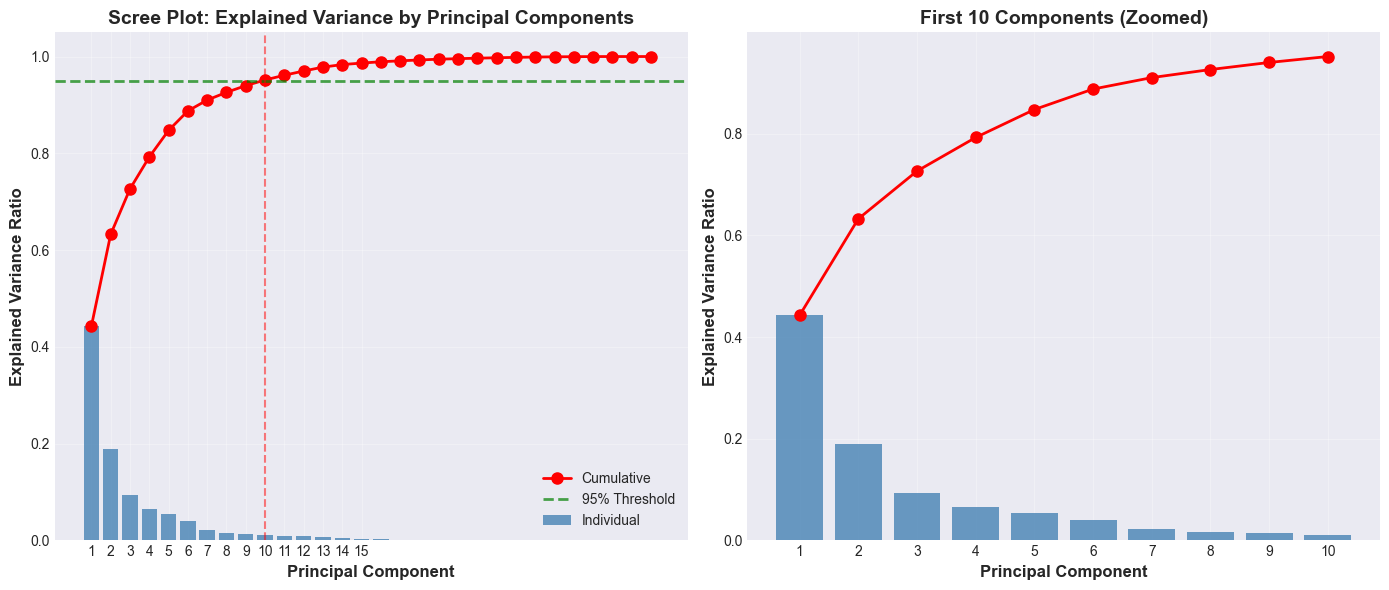

In [7]:
plt.figure(figsize=(14, 6))

# Subplot 1: Scree Plot
plt.subplot(1, 2, 1)
x_pos = np.arange(len(explained_variance)) + 1
bars = plt.bar(x_pos, explained_variance, alpha=0.8, color='steelblue', label='Individual')
plt.plot(x_pos, cumulative_variance, 'ro-', linewidth=2, markersize=8, label='Cumulative')

# Highlight 95% threshold
plt.axhline(y=0.95, color='green', linestyle='--', linewidth=2, alpha=0.7, label='95% Threshold')
plt.axvline(x=n_components_95, color='red', linestyle='--', linewidth=1.5, alpha=0.5)

plt.xlabel('Principal Component', fontsize=12, fontweight='bold')
plt.ylabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
plt.title('Scree Plot: Explained Variance by Principal Components', fontsize=14, fontweight='bold')
plt.xticks(x_pos[:15])  # Show first 15 components
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Zoomed in view (first 10 components)
plt.subplot(1, 2, 2)
plt.bar(x_pos[:10], explained_variance[:10], alpha=0.8, color='steelblue')
plt.plot(x_pos[:10], cumulative_variance[:10], 'ro-', linewidth=2, markersize=8)

plt.xlabel('Principal Component', fontsize=12, fontweight='bold')
plt.ylabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
plt.title('First 10 Components (Zoomed)', fontsize=14, fontweight='bold')
plt.xticks(x_pos[:10])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scree_plot_pca.png', dpi=120, bbox_inches='tight')
plt.show()

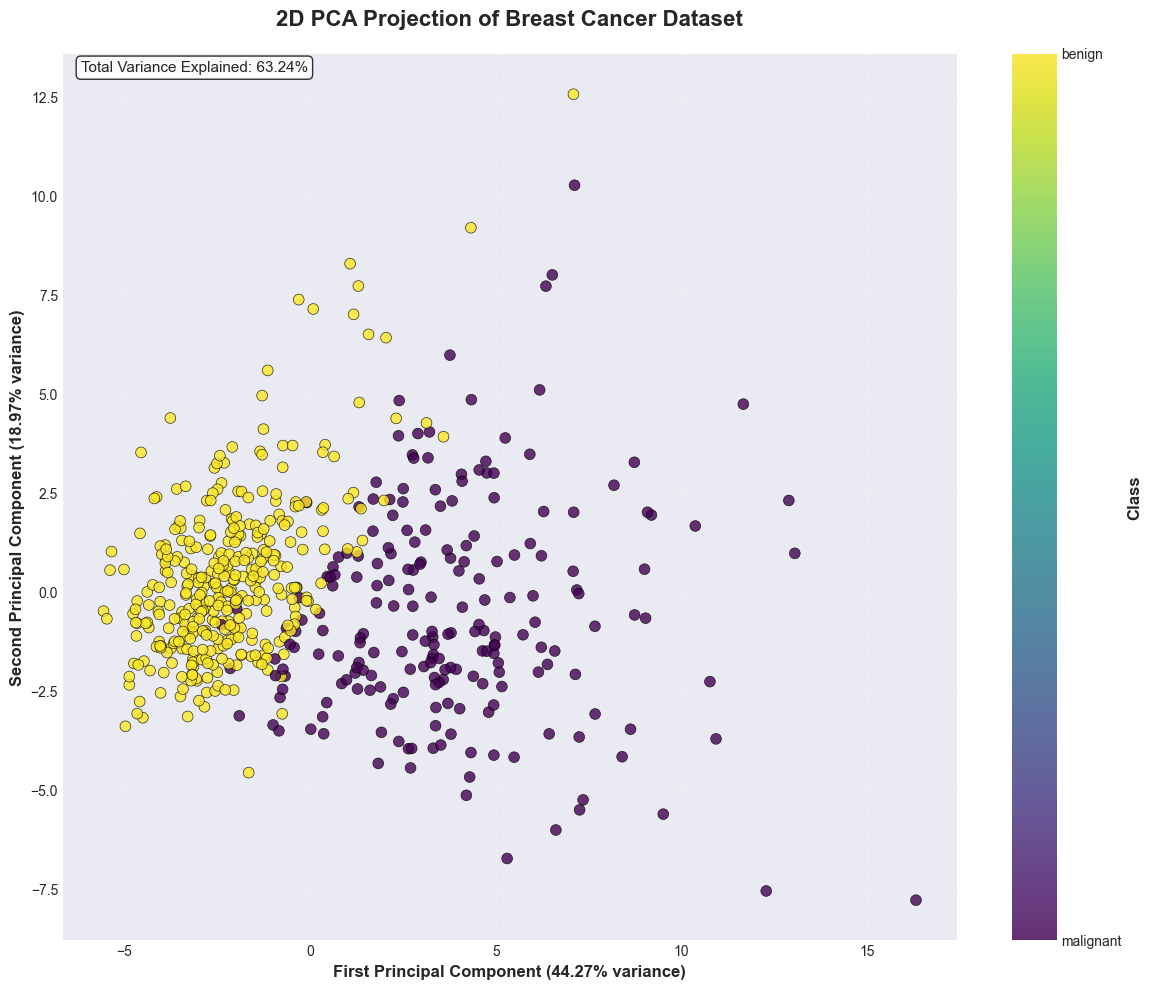

In [8]:
# Reduce to 2D for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(12, 10))

# Create scatter plot
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                      c=y, cmap='viridis', alpha=0.8, 
                      edgecolors='black', linewidth=0.5, s=60)

plt.xlabel(f'First Principal Component ({pca_2d.explained_variance_ratio_[0]:.2%} variance)', 
           fontsize=12, fontweight='bold')
plt.ylabel(f'Second Principal Component ({pca_2d.explained_variance_ratio_[1]:.2%} variance)', 
           fontsize=12, fontweight='bold')
plt.title('2D PCA Projection of Breast Cancer Dataset', fontsize=16, fontweight='bold', pad=20)

# Add colorbar for classes
cbar = plt.colorbar(scatter)
cbar.set_label('Class', fontsize=12, fontweight='bold')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(target_names)

# Add grid
plt.grid(True, alpha=0.3, linestyle='--')

# Add explained variance annotation
total_variance = pca_2d.explained_variance_ratio_.sum()
plt.annotate(f'Total Variance Explained: {total_variance:.2%}', 
             xy=(0.02, 0.98), xycoords='axes fraction',
             fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig('pca_2d_projection.png', dpi=120, bbox_inches='tight')
plt.show()

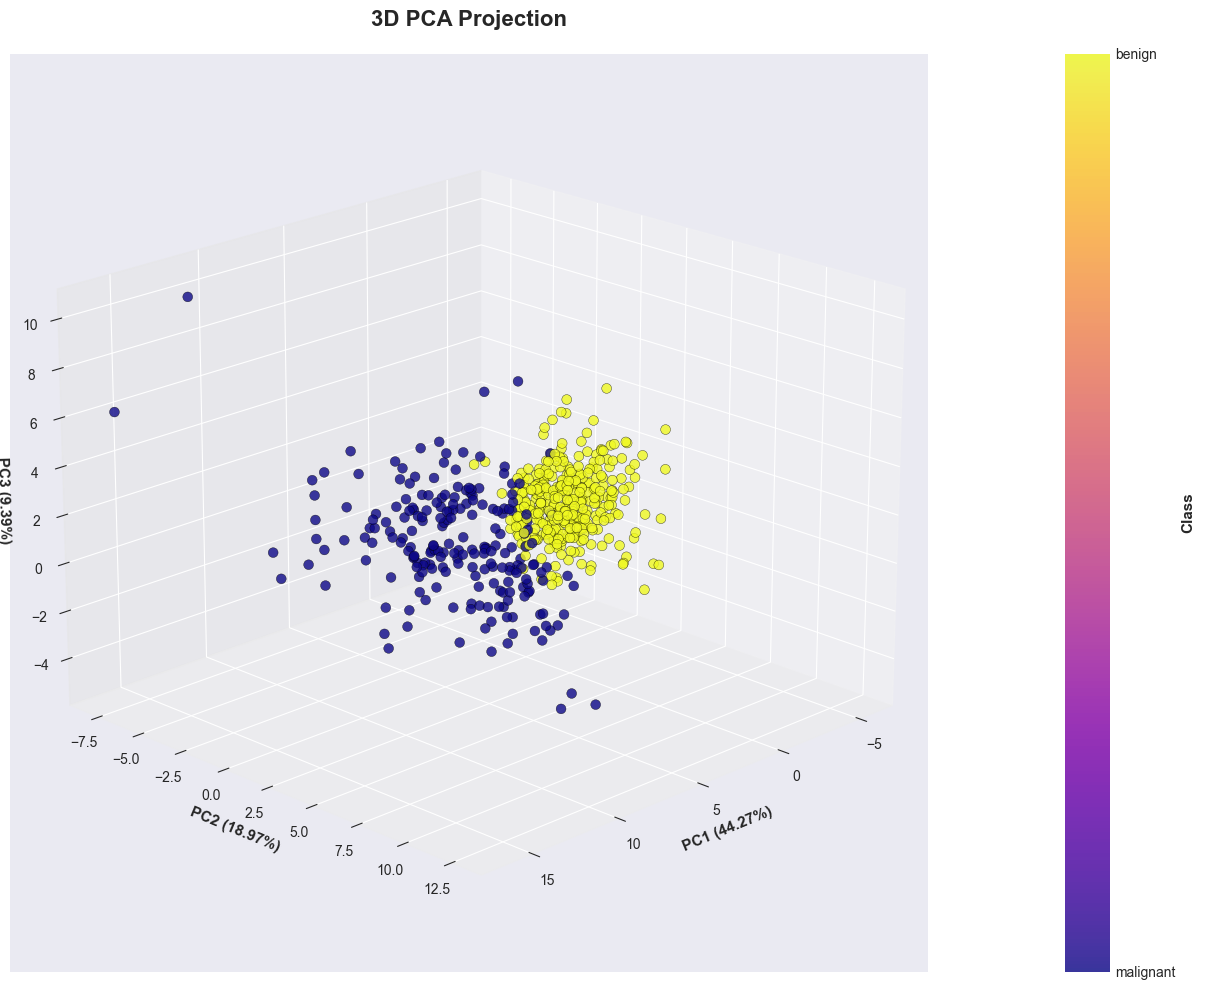

In [9]:
from mpl_toolkits.mplot3d import Axes3D

# Reduce to 3D for visualization
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Create 3D scatter plot
scatter = ax.scatter3D(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], 
                       c=y, cmap='plasma', alpha=0.8, 
                       edgecolors='black', linewidth=0.3, s=50)

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%})', fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%})', fontsize=11, fontweight='bold')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%})', fontsize=11, fontweight='bold')
ax.set_title('3D PCA Projection', fontsize=16, fontweight='bold', pad=20)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Class', fontsize=11, fontweight='bold')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(target_names)

# Adjust viewing angle
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.savefig('pca_3d_projection.png', dpi=120, bbox_inches='tight')
plt.show()

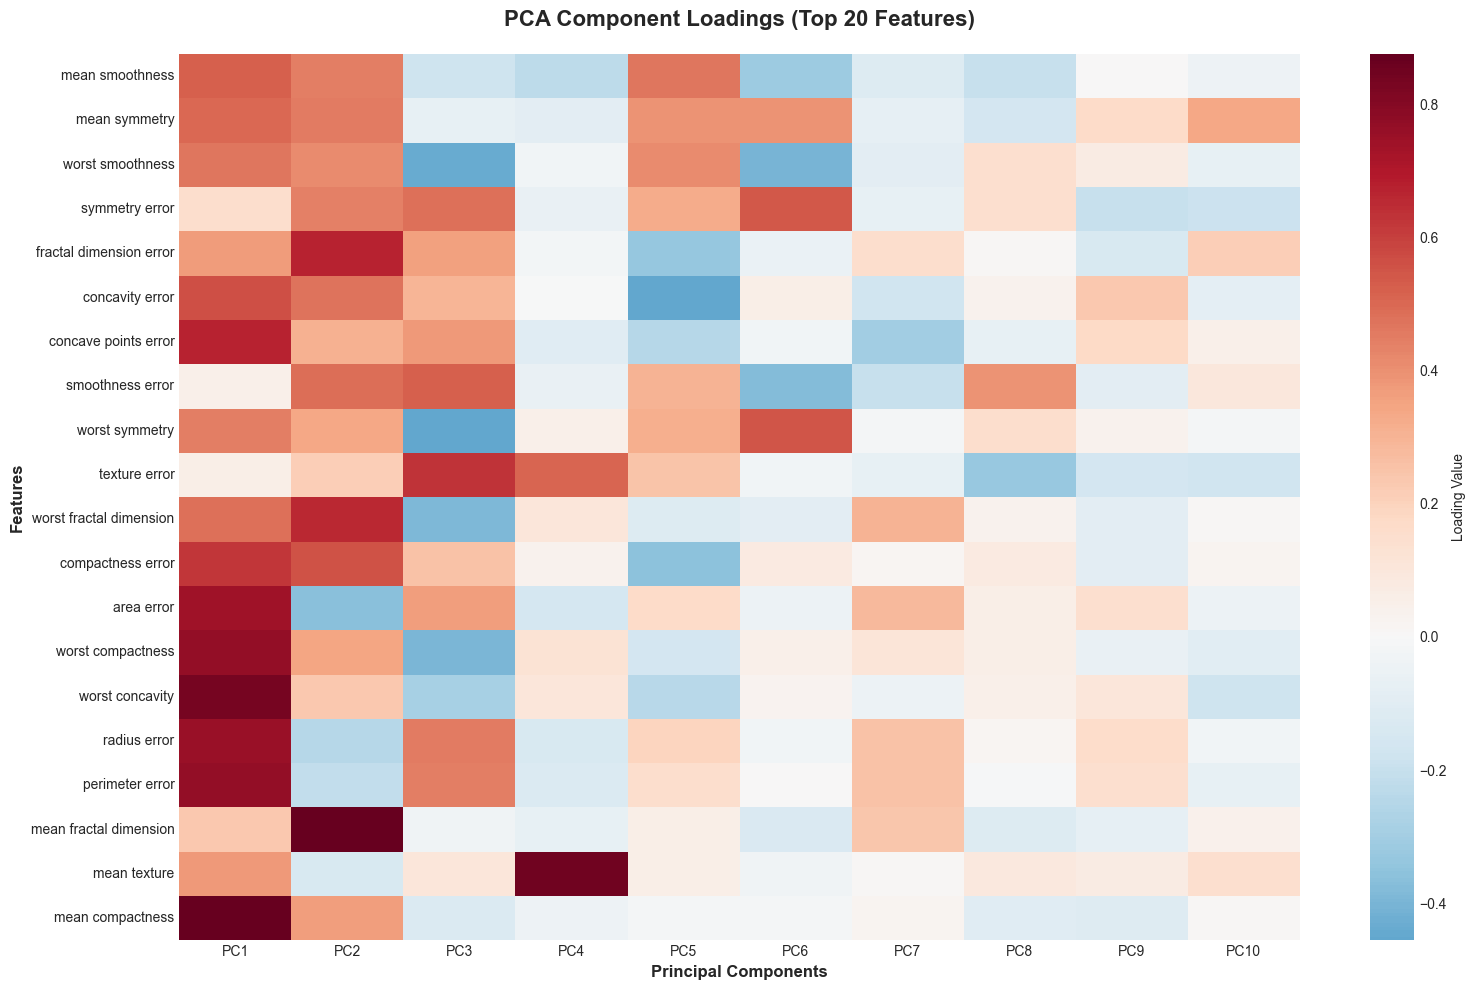

In [10]:
# Get loadings (feature contributions to components)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Create heatmap for first 10 components
plt.figure(figsize=(16, 10))

# Select top 20 features by absolute loading sum
loading_sums = np.sum(np.abs(loadings), axis=1)
top_features_idx = np.argsort(loading_sums)[-20:][::-1]

sns.heatmap(loadings[top_features_idx, :10], 
            cmap='RdBu_r', center=0,
            xticklabels=[f'PC{i+1}' for i in range(10)],
            yticklabels=np.array(feature_names)[top_features_idx],
            cbar_kws={'label': 'Loading Value'})

plt.title('PCA Component Loadings (Top 20 Features)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Principal Components', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_loadings_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

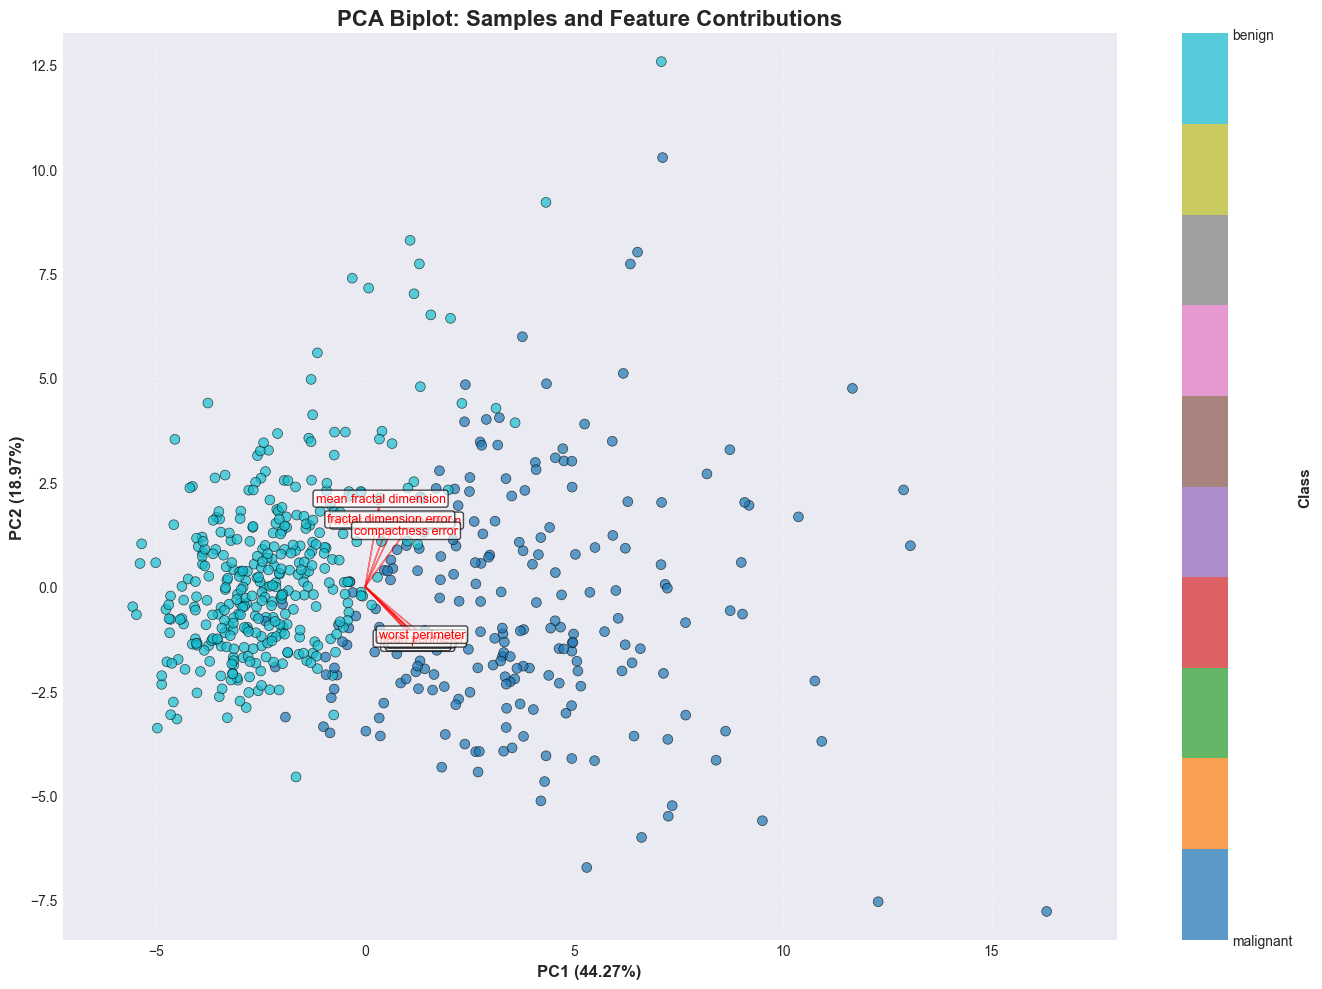

In [11]:
def plot_biplot(score, coeff, labels=None, scale=5):
    """Create a biplot showing both samples and feature contributions"""
    plt.figure(figsize=(14, 10))
    
    # Plot scores (samples)
    xs = score[:, 0]
    ys = score[:, 1]
    scatter = plt.scatter(xs, ys, c=y, cmap='tab10', alpha=0.7, 
                          edgecolors='black', linewidth=0.5, s=50)
    
    # Plot feature vectors
    for i in range(coeff.shape[0]):
        plt.arrow(0, 0, coeff[i, 0]*scale, coeff[i, 1]*scale, 
                  color='red', alpha=0.5, head_width=0.05)
        if labels is None:
            plt.text(coeff[i, 0]*scale*1.15, coeff[i, 1]*scale*1.15, 
                     f"Var{i+1}", color='red', ha='center', va='center', fontsize=9)
        else:
            plt.text(coeff[i, 0]*scale*1.15, coeff[i, 1]*scale*1.15, 
                     labels[i], color='red', ha='center', va='center', fontsize=9, 
                     bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
    
    plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})', fontsize=12, fontweight='bold')
    plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})', fontsize=12, fontweight='bold')
    plt.title('PCA Biplot: Samples and Feature Contributions', fontsize=16, fontweight='bold')
    
    # Add grid
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Add colorbar for classes
    cbar = plt.colorbar(scatter)
    cbar.set_label('Class', fontsize=11, fontweight='bold')
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(target_names)
    
    # Set equal aspect ratio
    plt.axis('equal')
    
    return plt

# Plot biplot with top 10 features by loading magnitude
loadings_2d = pca_2d.components_.T
loading_magnitudes = np.sqrt(np.sum(loadings_2d**2, axis=1))
top_features_idx = np.argsort(loading_magnitudes)[-10:][::-1]

plot_biplot(X_pca_2d, loadings_2d[top_features_idx], 
            labels=np.array(feature_names)[top_features_idx])
plt.tight_layout()
plt.savefig('pca_biplot.png', dpi=120, bbox_inches='tight')
plt.show()

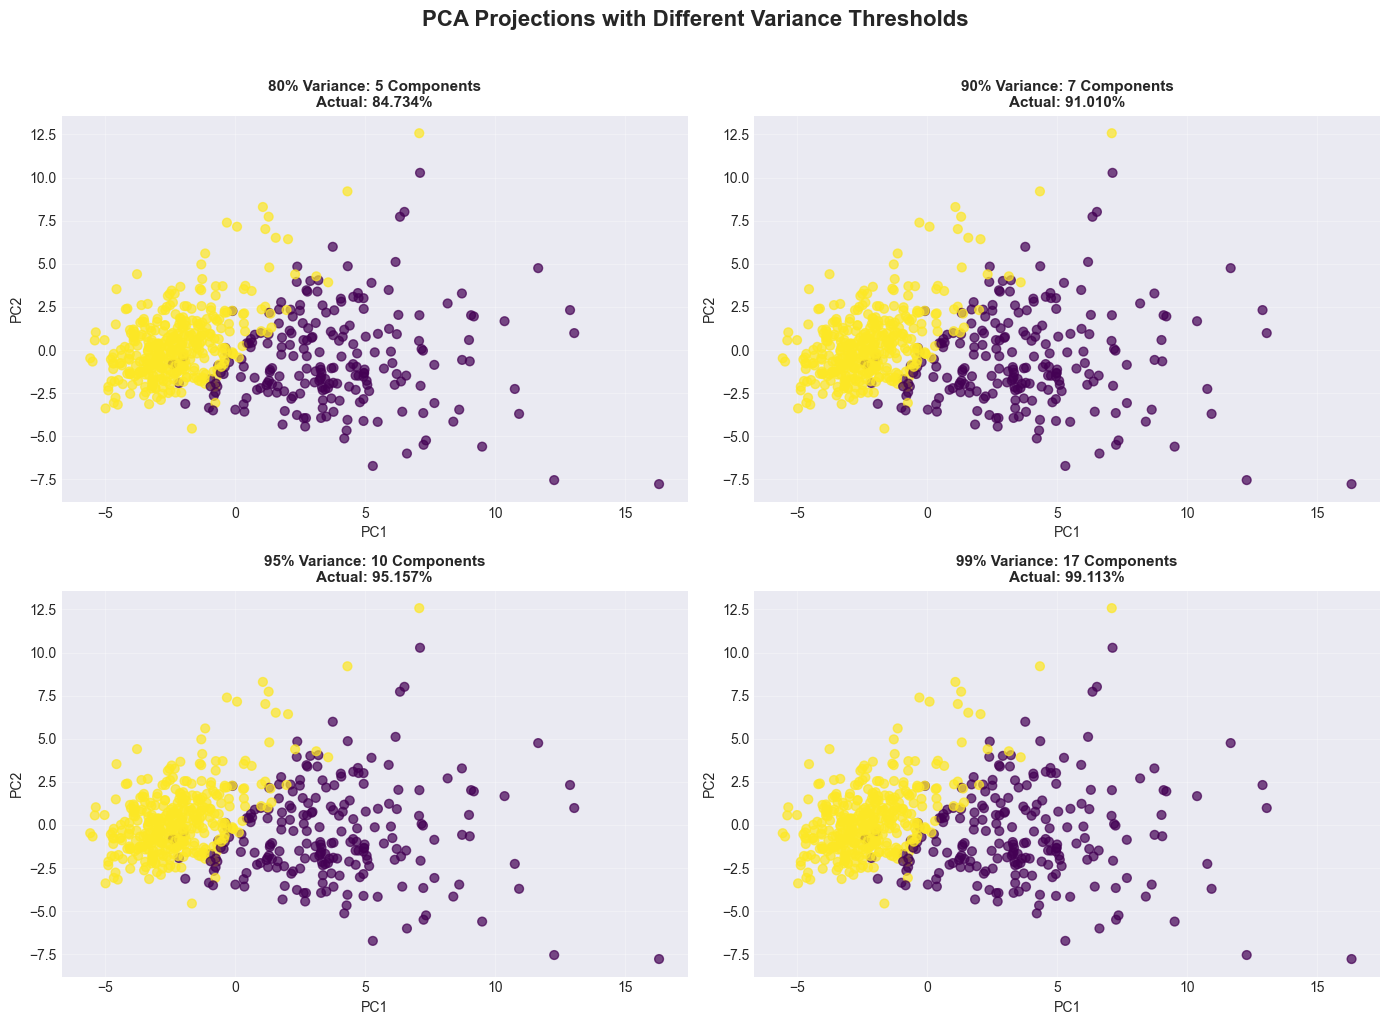


PCA Variance Threshold Summary:
 Variance Threshold  Components Required  Actual Variance
               0.80                    5         0.847343
               0.90                    7         0.910095
               0.95                   10         0.951569
               0.99                   17         0.991130


In [12]:
# Try different variance thresholds
var_thresholds = [0.80, 0.90, 0.95, 0.99]
n_components_list = []
var_explained_list = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, threshold in enumerate(var_thresholds):
    # Find number of components for threshold
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    n_components_list.append(n_components)
    var_explained_list.append(cumulative_variance[n_components-1])
    
    # Apply PCA with this number of components
    pca_thresh = PCA(n_components=n_components)
    X_pca_thresh = pca_thresh.fit_transform(X_scaled)
    
    # Plot first two components
    ax = axes[idx]
    scatter = ax.scatter(X_pca_thresh[:, 0], X_pca_thresh[:, 1], 
                         c=y, cmap='viridis', alpha=0.7, s=40)
    
    ax.set_title(f'{threshold:.0%} Variance: {n_components} Components\nActual: {cumulative_variance[n_components-1]:.3%}', 
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(f'PC1')
    ax.set_ylabel(f'PC2')
    ax.grid(True, alpha=0.3)

plt.suptitle('PCA Projections with Different Variance Thresholds', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pca_variance_thresholds.png', dpi=120, bbox_inches='tight')
plt.show()

# Summary table
summary_df = pd.DataFrame({
    'Variance Threshold': var_thresholds,
    'Components Required': n_components_list,
    'Actual Variance': var_explained_list
})
print("\nPCA Variance Threshold Summary:")
print(summary_df.to_string(index=False))

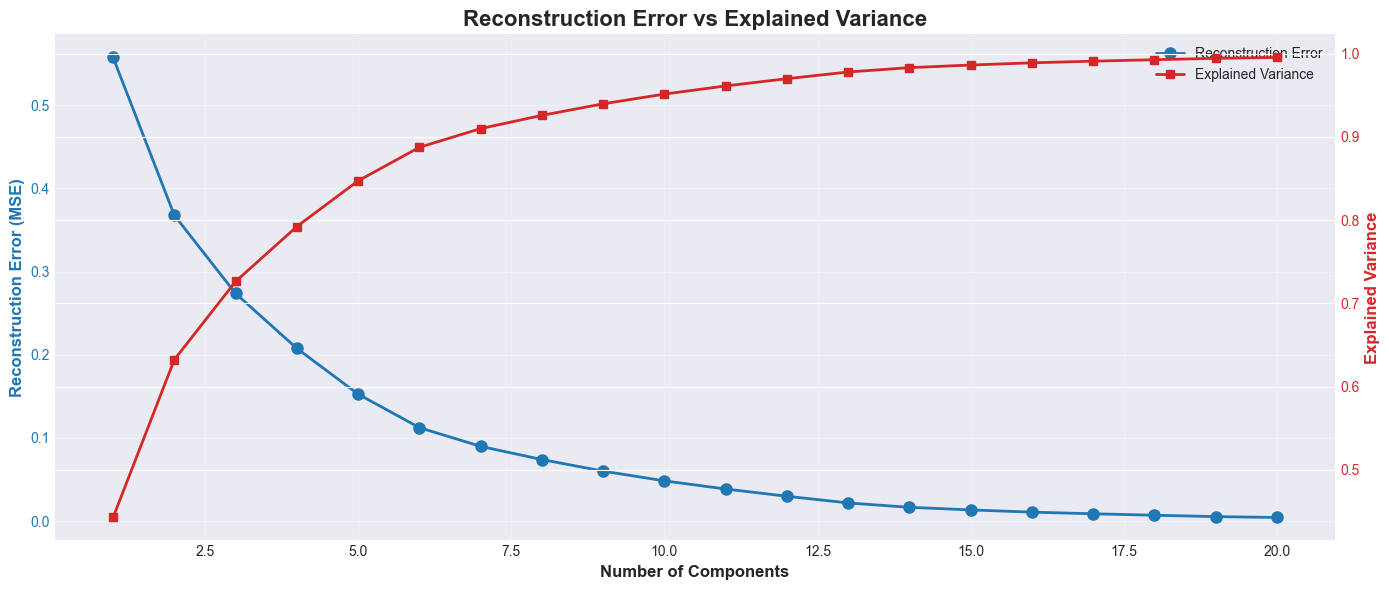

In [13]:
# Analyze reconstruction error for different n_components
n_components_range = range(1, min(20, X.shape[1]) + 1)
reconstruction_errors = []
explained_variances = []

for n in n_components_range:
    pca_temp = PCA(n_components=n)
    X_pca_temp = pca_temp.fit_transform(X_scaled)
    X_reconstructed = pca_temp.inverse_transform(X_pca_temp)
    
    # Calculate reconstruction error (MSE)
    mse = np.mean((X_scaled - X_reconstructed) ** 2)
    reconstruction_errors.append(mse)
    explained_variances.append(np.sum(pca_temp.explained_variance_ratio_))

# Plot reconstruction error vs explained variance
fig, ax1 = plt.figure(figsize=(14, 6)), plt.gca()

color1 = 'tab:blue'
ax1.set_xlabel('Number of Components', fontsize=12, fontweight='bold')
ax1.set_ylabel('Reconstruction Error (MSE)', color=color1, fontsize=12, fontweight='bold')
line1 = ax1.plot(n_components_range, reconstruction_errors, 'o-', 
                 color=color1, linewidth=2, markersize=8, label='Reconstruction Error')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Second y-axis for explained variance
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Explained Variance', color=color2, fontsize=12, fontweight='bold')
line2 = ax2.plot(n_components_range, explained_variances, 's-', 
                 color=color2, linewidth=2, markersize=6, label='Explained Variance')
ax2.tick_params(axis='y', labelcolor=color2)

# Add combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('Reconstruction Error vs Explained Variance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_reconstruction_error.png', dpi=120, bbox_inches='tight')
plt.show()


Configuration: Original (30 features)
Number of features: 30
Accuracy: 0.9708

Configuration: PCA (95% variance)
Explained variance: 95.139%
Number of features: 10
Accuracy: 0.9591

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.94      0.94        63
      benign       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171


Configuration: PCA (10 components)
Explained variance: 95.139%
Number of features: 10
Accuracy: 0.9591

Configuration: PCA (5 components)
Explained variance: 84.490%
Number of features: 5
Accuracy: 0.9649

Configuration: PCA (2 components)
Explained variance: 63.013%
Number of features: 2
Accuracy: 0.9532

FINAL COMPARISON RESULTS
                Config  Features  Accuracy
Original (30 features)        30  0.970760
    PCA (95% variance)        10  0.959064
   P

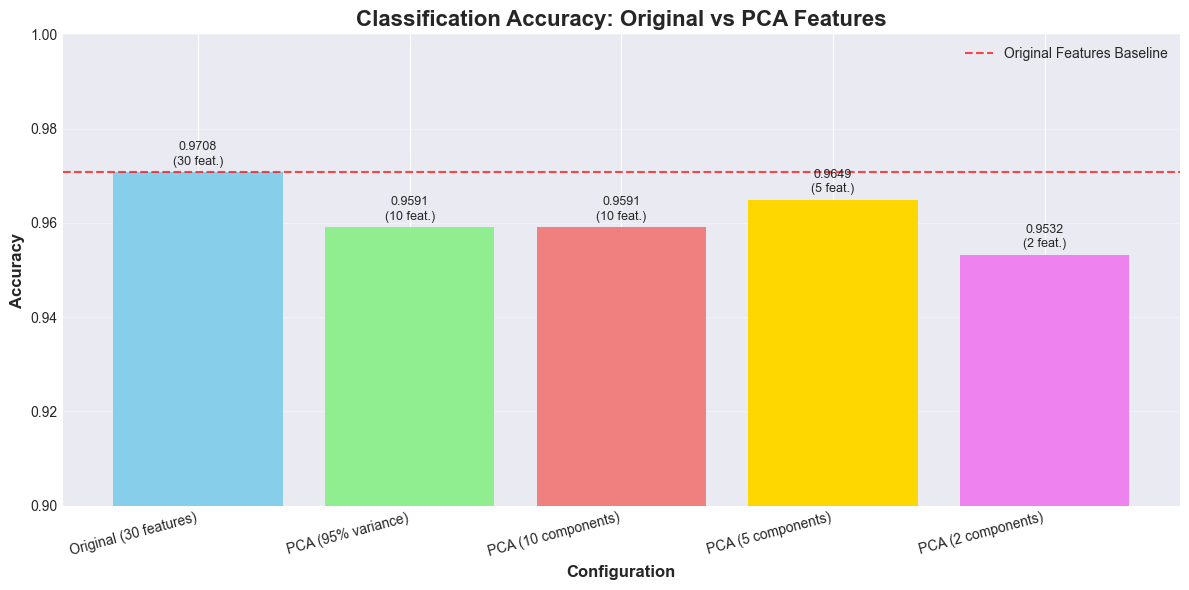

In [14]:
# Compare classification performance with/without PCA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define different PCA configurations
configs = [
    {'name': 'Original (30 features)', 'n_components': None},
    {'name': 'PCA (95% variance)', 'n_components': 0.95},
    {'name': 'PCA (10 components)', 'n_components': 10},
    {'name': 'PCA (5 components)', 'n_components': 5},
    {'name': 'PCA (2 components)', 'n_components': 2}
]

results = []

for config in configs:
    print(f"\n{'='*60}")
    print(f"Configuration: {config['name']}")
    print('='*60)
    
    if config['n_components'] is None:
        # Use original features
        X_train_processed = X_train_scaled
        X_test_processed = X_test_scaled
        n_features = X_train_scaled.shape[1]
    else:
        # Apply PCA
        if config['n_components'] <= 1:
            pca_temp = PCA(n_components=config['n_components'])
        else:
            pca_temp = PCA(n_components=min(config['n_components'], X_train_scaled.shape[1]))
        
        X_train_processed = pca_temp.fit_transform(X_train_scaled)
        X_test_processed = pca_temp.transform(X_test_scaled)
        n_features = X_train_processed.shape[1]
        
        if hasattr(pca_temp, 'explained_variance_ratio_'):
            explained_var = np.sum(pca_temp.explained_variance_ratio_)
            print(f"Explained variance: {explained_var:.3%}")
    
    print(f"Number of features: {n_features}")
    
    # Train classifier
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train_processed, y_train)
    
    # Make predictions
    y_pred = clf.predict(X_test_processed)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    results.append({
        'Config': config['name'],
        'Features': n_features,
        'Accuracy': accuracy
    })
    
    print(f"Accuracy: {accuracy:.4f}")
    
    # Print classification report for the best configuration
    if config['name'] == 'PCA (95% variance)':
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=target_names))

# Create results comparison DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("FINAL COMPARISON RESULTS")
print("="*60)
print(results_df.to_string(index=False))

# Plot comparison
plt.figure(figsize=(12, 6))
bars = plt.bar(results_df['Config'], results_df['Accuracy'], 
               color=['skyblue', 'lightgreen', 'lightcoral', 'gold', 'violet'])
plt.axhline(y=results_df.loc[0, 'Accuracy'], color='red', linestyle='--', 
            alpha=0.7, label='Original Features Baseline')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Configuration', fontsize=12, fontweight='bold')
plt.title('Classification Accuracy: Original vs PCA Features', fontsize=16, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.ylim([0.9, 1.0])
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, result in zip(bars, results_df.itertuples()):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{result.Accuracy:.4f}\n({result.Features} feat.)',
             ha='center', va='bottom', fontsize=9)

plt.legend()
plt.tight_layout()
plt.savefig('pca_classification_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
# Interactive 3D plot (requires ipympl or plotly)
try:
    import plotly.graph_objects as go
    import plotly.express as px
    
    # Create interactive 3D plot
    pca_3d = PCA(n_components=3)
    X_pca_3d = pca_3d.fit_transform(X_scaled)
    
    # Create DataFrame for plotly
    plotly_df = pd.DataFrame({
        'PC1': X_pca_3d[:, 0],
        'PC2': X_pca_3d[:, 1],
        'PC3': X_pca_3d[:, 2],
        'Class': y,
        'Class_Name': np.where(y == 0, target_names[0], target_names[1])
    })
    
    # Create 3D scatter plot
    fig = px.scatter_3d(plotly_df, x='PC1', y='PC2', z='PC3',
                        color='Class_Name',
                        title='Interactive 3D PCA Visualization',
                        labels={'Class_Name': 'Diagnosis'},
                        opacity=0.8,
                        hover_data={'Class': True})
    
    fig.update_layout(
        scene=dict(
            xaxis_title=f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%})',
            yaxis_title=f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%})',
            zaxis_title=f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%})'
        ),
        legend_title_text='Diagnosis'
    )
    
    # Save as HTML for interactive viewing
    fig.write_html("interactive_pca_3d.html")
    print("Interactive 3D plot saved as 'interactive_pca_3d.html'")
    
except ImportError:
    print("Plotly not installed. Install with: pip install plotly")

Interactive 3D plot saved as 'interactive_pca_3d.html'


In [16]:
# Create final summary
print("\n" + "="*70)
print("PCA IMPLEMENTATION SUMMARY")
print("="*70)

# Dimensionality reduction summary
print(f"\n1. DIMENSIONALITY REDUCTION:")
print(f"   Original features: {X.shape[1]}")
print(f"   95% variance requires: {n_components_95} components")
print(f"   Reduction: {100 * (1 - n_components_95/X.shape[1]):.1f}%")

# Key components analysis
print(f"\n2. KEY COMPONENTS ANALYSIS:")
print(f"   PC1 explains: {explained_variance[0]:.2%} of variance")
print(f"   PC2 explains: {explained_variance[1]:.2%} of variance")
print(f"   First 5 components explain: {cumulative_variance[4]:.2%} of variance")

# Feature importance
print(f"\n3. TOP FEATURES IN PC1:")
loadings_pc1 = pd.DataFrame({
    'Feature': feature_names,
    'Loading_PC1': pca.components_[0],
    'Abs_Loading': np.abs(pca.components_[0])
})
top_features_pc1 = loadings_pc1.sort_values('Abs_Loading', ascending=False).head(5)
for idx, row in top_features_pc1.iterrows():
    print(f"   {row['Feature']}: {row['Loading_PC1']:.3f}")

# Practical recommendations
print(f"\n4. PRACTICAL RECOMMENDATIONS:")
print(f"   • Use {n_components_95} components for production (95% variance)")
print(f"   • Use 2-3 components for visualization")
print(f"   • Always standardize before PCA")
print(f"   • Consider 10-15 components for downstream ML tasks")


PCA IMPLEMENTATION SUMMARY

1. DIMENSIONALITY REDUCTION:
   Original features: 30
   95% variance requires: 10 components
   Reduction: 66.7%

2. KEY COMPONENTS ANALYSIS:
   PC1 explains: 44.27% of variance
   PC2 explains: 18.97% of variance
   First 5 components explain: 84.73% of variance

3. TOP FEATURES IN PC1:
   mean concave points: 0.261
   mean concavity: 0.258
   worst concave points: 0.251
   mean compactness: 0.239
   worst perimeter: 0.237

4. PRACTICAL RECOMMENDATIONS:
   • Use 10 components for production (95% variance)
   • Use 2-3 components for visualization
   • Always standardize before PCA
   • Consider 10-15 components for downstream ML tasks


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Set style for better visualizations
plt.style.use('default')
sns.set_style("whitegrid")

In [19]:
# Generate simple 2D data with correlation
np.random.seed(42)

# Create correlated data
n_samples = 200
x1 = np.random.randn(n_samples) * 2
x2 = 0.7 * x1 + np.random.randn(n_samples) * 1  # x2 is correlated with x1

# Add some noise
x1 = x1 + np.random.randn(n_samples) * 0.5
x2 = x2 + np.random.randn(n_samples) * 0.5

# Combine into 2D array
X = np.column_stack((x1, x2))

# Create labels for visualization (not used in PCA, just for colors)
y = (x1 + x2) > 0  # Simple binary classification

print(f"Data shape: {X.shape}")
print(f"Feature 1 mean: {x1.mean():.2f}, std: {x1.std():.2f}")
print(f"Feature 2 mean: {x2.mean():.2f}, std: {x2.std():.2f}")
print(f"Correlation between features: {np.corrcoef(x1, x2)[0,1]:.3f}")

Data shape: (200, 2)
Feature 1 mean: -0.12, std: 1.86
Feature 2 mean: 0.03, std: 1.77
Correlation between features: 0.782


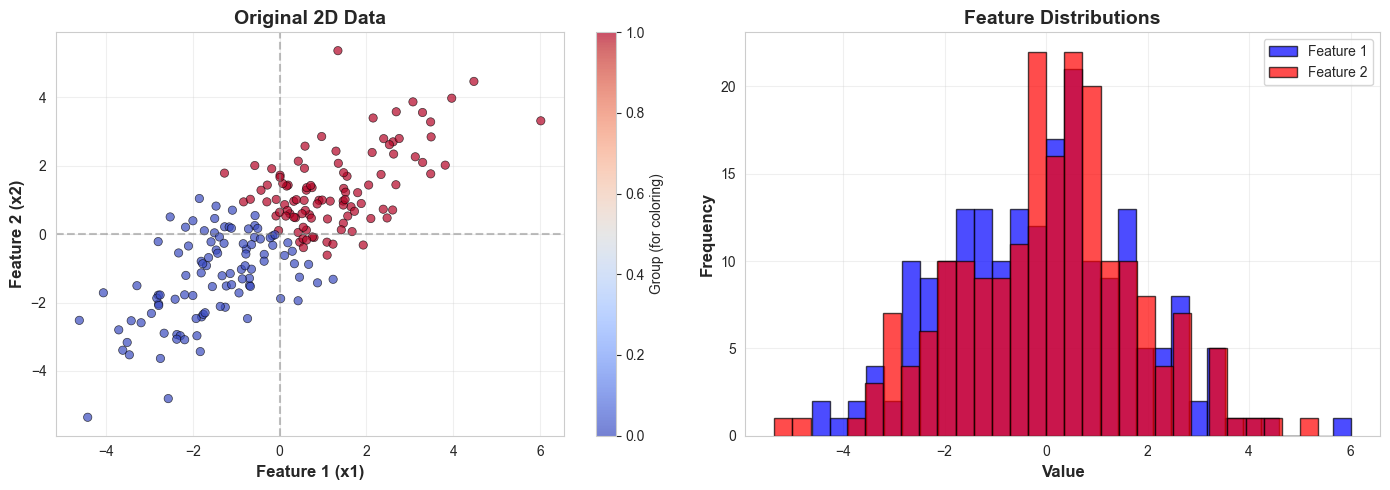

In [20]:
# Plot original 2D data
plt.figure(figsize=(14, 5))

# Subplot 1: Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='black', linewidth=0.5)
plt.xlabel('Feature 1 (x1)', fontsize=12, fontweight='bold')
plt.ylabel('Feature 2 (x2)', fontsize=12, fontweight='bold')
plt.title('Original 2D Data', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.colorbar(label='Group (for coloring)')

# Subplot 2: Histograms
plt.subplot(1, 2, 2)
plt.hist(x1, bins=30, alpha=0.7, label='Feature 1', color='blue', edgecolor='black')
plt.hist(x2, bins=30, alpha=0.7, label='Feature 2', color='red', edgecolor='black')
plt.xlabel('Value', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Feature Distributions', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('1_original_data.png', dpi=100, bbox_inches='tight')
plt.show()

Before standardization:
  Feature 1 - Mean: -0.12, Std: 1.86
  Feature 2 - Mean: 0.03, Std: 1.77

After standardization:
  Feature 1 - Mean: 0.00, Std: 1.00
  Feature 2 - Mean: 0.00, Std: 1.00


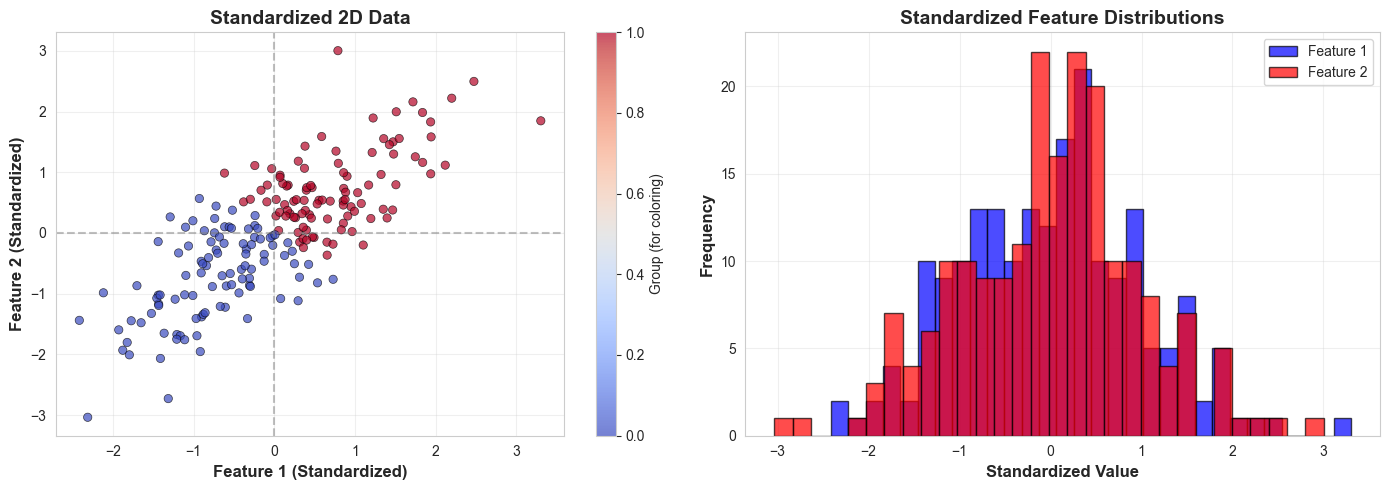

In [21]:
# Standardize the data (important for PCA!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before standardization:")
print(f"  Feature 1 - Mean: {X[:, 0].mean():.2f}, Std: {X[:, 0].std():.2f}")
print(f"  Feature 2 - Mean: {X[:, 1].mean():.2f}, Std: {X[:, 1].std():.2f}")

print("\nAfter standardization:")
print(f"  Feature 1 - Mean: {X_scaled[:, 0].mean():.2f}, Std: {X_scaled[:, 0].std():.2f}")
print(f"  Feature 2 - Mean: {X_scaled[:, 1].mean():.2f}, Std: {X_scaled[:, 1].std():.2f}")

# Plot standardized data
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='black', linewidth=0.5)
plt.xlabel('Feature 1 (Standardized)', fontsize=12, fontweight='bold')
plt.ylabel('Feature 2 (Standardized)', fontsize=12, fontweight='bold')
plt.title('Standardized 2D Data', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.colorbar(label='Group (for coloring)')

plt.subplot(1, 2, 2)
plt.hist(X_scaled[:, 0], bins=30, alpha=0.7, label='Feature 1', color='blue', edgecolor='black')
plt.hist(X_scaled[:, 1], bins=30, alpha=0.7, label='Feature 2', color='red', edgecolor='black')
plt.xlabel('Standardized Value', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Standardized Feature Distributions', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('2_standardized_data.png', dpi=100, bbox_inches='tight')
plt.show()

PCA Results:
Principal Components (Eigenvectors):
  PC1: [0.70710678 0.70710678]
  PC2: [-0.70710678  0.70710678]

Explained Variance (Eigenvalues):
  PC1: 1.7906
  PC2: 0.2194

Explained Variance Ratio (% of total variance):
  PC1: 89.08%
  PC2: 10.92%
  Total: 100.00%


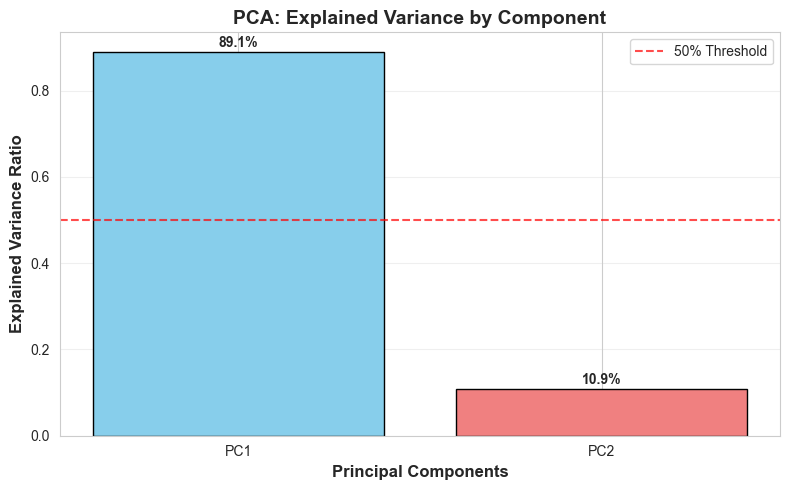

In [22]:
# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Get PCA components and explained variance
print("PCA Results:")
print(f"Principal Components (Eigenvectors):")
print(f"  PC1: {pca.components_[0]}")
print(f"  PC2: {pca.components_[1]}")

print(f"\nExplained Variance (Eigenvalues):")
print(f"  PC1: {pca.explained_variance_[0]:.4f}")
print(f"  PC2: {pca.explained_variance_[1]:.4f}")

print(f"\nExplained Variance Ratio (% of total variance):")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.2%}")

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.bar(['PC1', 'PC2'], pca.explained_variance_ratio_, color=['skyblue', 'lightcoral'], edgecolor='black')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='50% Threshold')
plt.xlabel('Principal Components', fontsize=12, fontweight='bold')
plt.ylabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
plt.title('PCA: Explained Variance by Component', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Add values on top of bars
for i, v in enumerate(pca.explained_variance_ratio_):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('3_explained_variance.png', dpi=100, bbox_inches='tight')
plt.show()

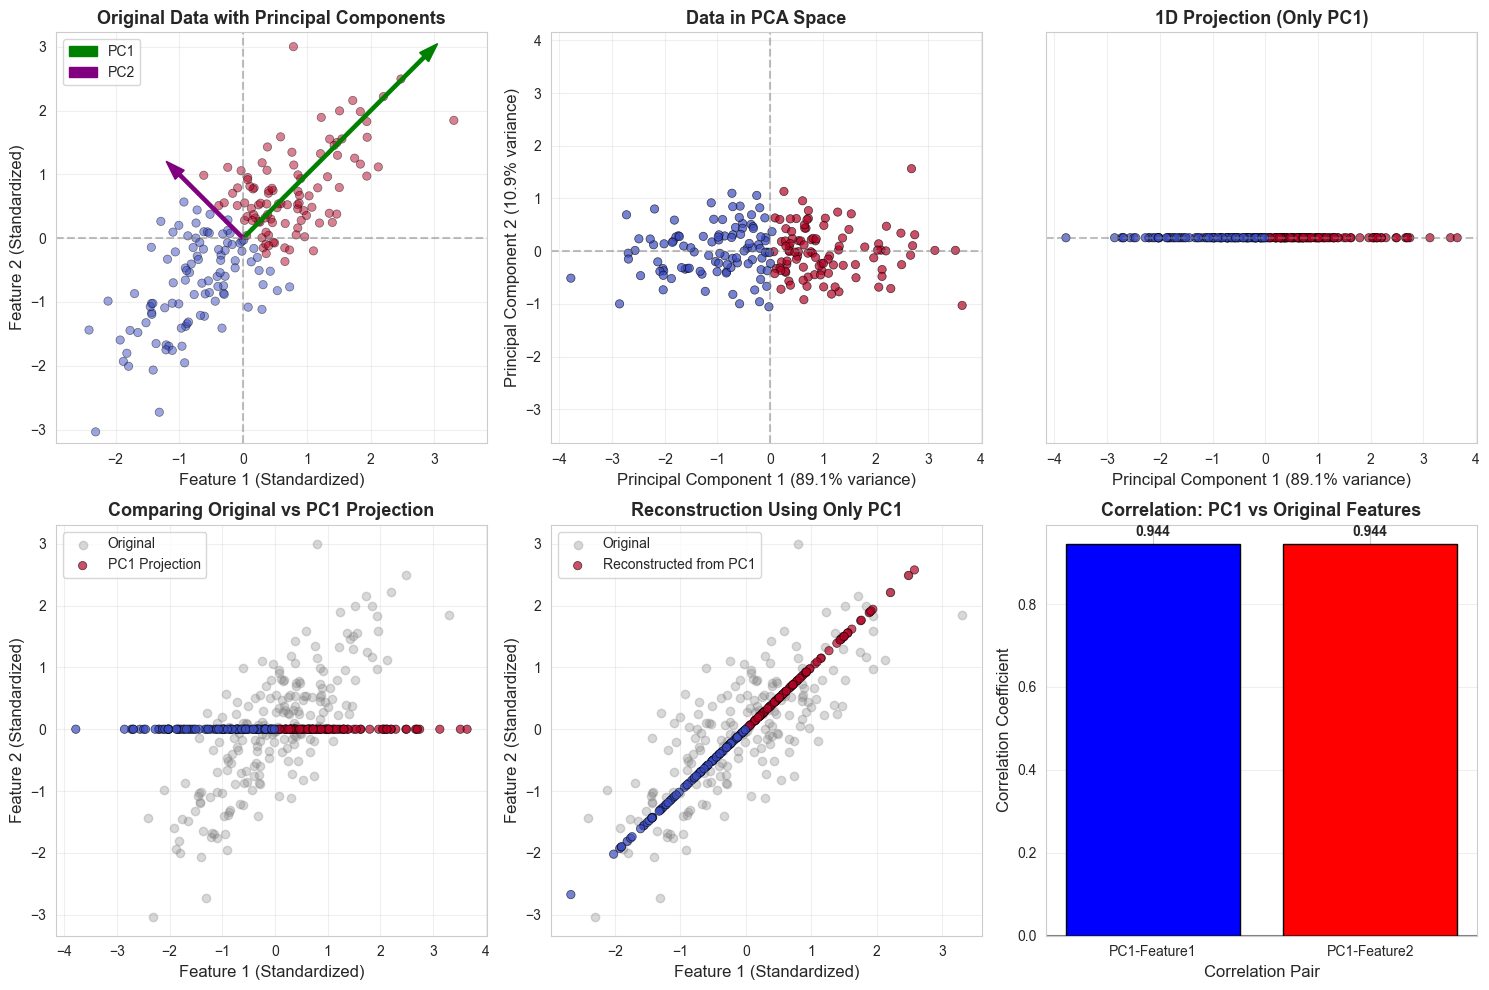

In [23]:
# Create a comprehensive visualization
plt.figure(figsize=(15, 10))

# Subplot 1: Original data with PCA components
plt.subplot(2, 3, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='coolwarm', alpha=0.5, edgecolors='black', linewidth=0.5)

# Draw principal components as arrows
origin = [0, 0]
pc1 = pca.components_[0] * np.sqrt(pca.explained_variance_[0]) * 3  # Scale for visibility
pc2 = pca.components_[1] * np.sqrt(pca.explained_variance_[1]) * 3

plt.arrow(origin[0], origin[1], pc1[0], pc1[1], color='green', width=0.05, head_width=0.2, label='PC1')
plt.arrow(origin[0], origin[1], pc2[0], pc2[1], color='purple', width=0.05, head_width=0.2, label='PC2')

plt.xlabel('Feature 1 (Standardized)', fontsize=12)
plt.ylabel('Feature 2 (Standardized)', fontsize=12)
plt.title('Original Data with Principal Components', fontsize=13, fontweight='bold')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Subplot 2: Transformed data (PCA space)
plt.subplot(2, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='black', linewidth=0.5)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title('Data in PCA Space', fontsize=13, fontweight='bold')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Subplot 3: PC1 only (1D projection)
plt.subplot(2, 3, 3)
plt.scatter(X_pca[:, 0], np.zeros_like(X_pca[:, 0]), c=y, cmap='coolwarm', alpha=0.7, edgecolors='black', linewidth=0.5)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.title('1D Projection (Only PC1)', fontsize=13, fontweight='bold')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.yticks([])  # Hide y-axis for 1D plot

# Subplot 4: Original vs PC1
plt.subplot(2, 3, 4)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.3, color='gray', label='Original')
plt.scatter(X_pca[:, 0], np.zeros_like(X_pca[:, 0]), c=y, cmap='coolwarm', 
            alpha=0.7, edgecolors='black', linewidth=0.5, label='PC1 Projection')
plt.xlabel('Feature 1 (Standardized)', fontsize=12)
plt.ylabel('Feature 2 (Standardized)', fontsize=12)
plt.title('Comparing Original vs PC1 Projection', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 5: Reconstruction from PC1 only
X_reconstructed = pca.inverse_transform(np.column_stack((X_pca[:, 0], np.zeros_like(X_pca[:, 0]))))
plt.subplot(2, 3, 5)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.3, color='gray', label='Original')
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], c=y, cmap='coolwarm', 
            alpha=0.7, edgecolors='black', linewidth=0.5, label='Reconstructed from PC1')
plt.xlabel('Feature 1 (Standardized)', fontsize=12)
plt.ylabel('Feature 2 (Standardized)', fontsize=12)
plt.title('Reconstruction Using Only PC1', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 6: PC1 vs Feature correlation
plt.subplot(2, 3, 6)
# Calculate correlation between PC1 and original features
corr_pc1_feat1 = np.corrcoef(X_scaled[:, 0], X_pca[:, 0])[0, 1]
corr_pc1_feat2 = np.corrcoef(X_scaled[:, 1], X_pca[:, 0])[0, 1]

plt.bar(['PC1-Feature1', 'PC1-Feature2'], [corr_pc1_feat1, corr_pc1_feat2], 
        color=['blue', 'red'], edgecolor='black')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
plt.xlabel('Correlation Pair', fontsize=12)
plt.ylabel('Correlation Coefficient', fontsize=12)
plt.title('Correlation: PC1 vs Original Features', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add correlation values on bars
plt.text(0, corr_pc1_feat1 + 0.02 * np.sign(corr_pc1_feat1), f'{corr_pc1_feat1:.3f}', 
         ha='center', fontweight='bold')
plt.text(1, corr_pc1_feat2 + 0.02 * np.sign(corr_pc1_feat2), f'{corr_pc1_feat2:.3f}', 
         ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('4_pca_visualization.png', dpi=100, bbox_inches='tight')
plt.show()

STEP-BY-STEP PCA CALCULATION

1. Standardized data (first 5 points):
[[ 0.17263693  0.78831624]
 [-0.24332294 -0.07167199]
 [ 0.76595642  1.34805801]
 [ 1.71995044  2.15939407]
 [-0.30639478 -0.86364632]]

2. Covariance matrix:
[[1.00502513 0.7855762 ]
 [0.7855762  1.00502513]]

3. Eigenvalues (variance):
  λ1: 1.7906
  λ2: 0.2194

4. Eigenvectors (principal components):
  v1 (PC1): [0.70710678 0.70710678]
  v2 (PC2): [-0.70710678  0.70710678]

5. Sorted (descending by eigenvalue):
  λ1: 1.7906, v1: [0.70710678 0.70710678]
  λ2: 0.2194, v2: [-0.70710678  0.70710678]

6. Manual PCA projection (first 5 points):
[[ 0.67949651  0.43535101]
 [-0.22273505  0.12137555]
 [ 1.49483393  0.41160798]
 [ 2.7431108   0.31073357]
 [-0.827344   -0.39403634]]

7. Compare with sklearn PCA (first 5 points):
[[ 0.67949651  0.43535101]
 [-0.22273505  0.12137555]
 [ 1.49483393  0.41160798]
 [ 2.7431108   0.31073357]
 [-0.827344   -0.39403634]]

8. Explained variance ratio:
  PC1: 89.08%
  PC2: 10.92%


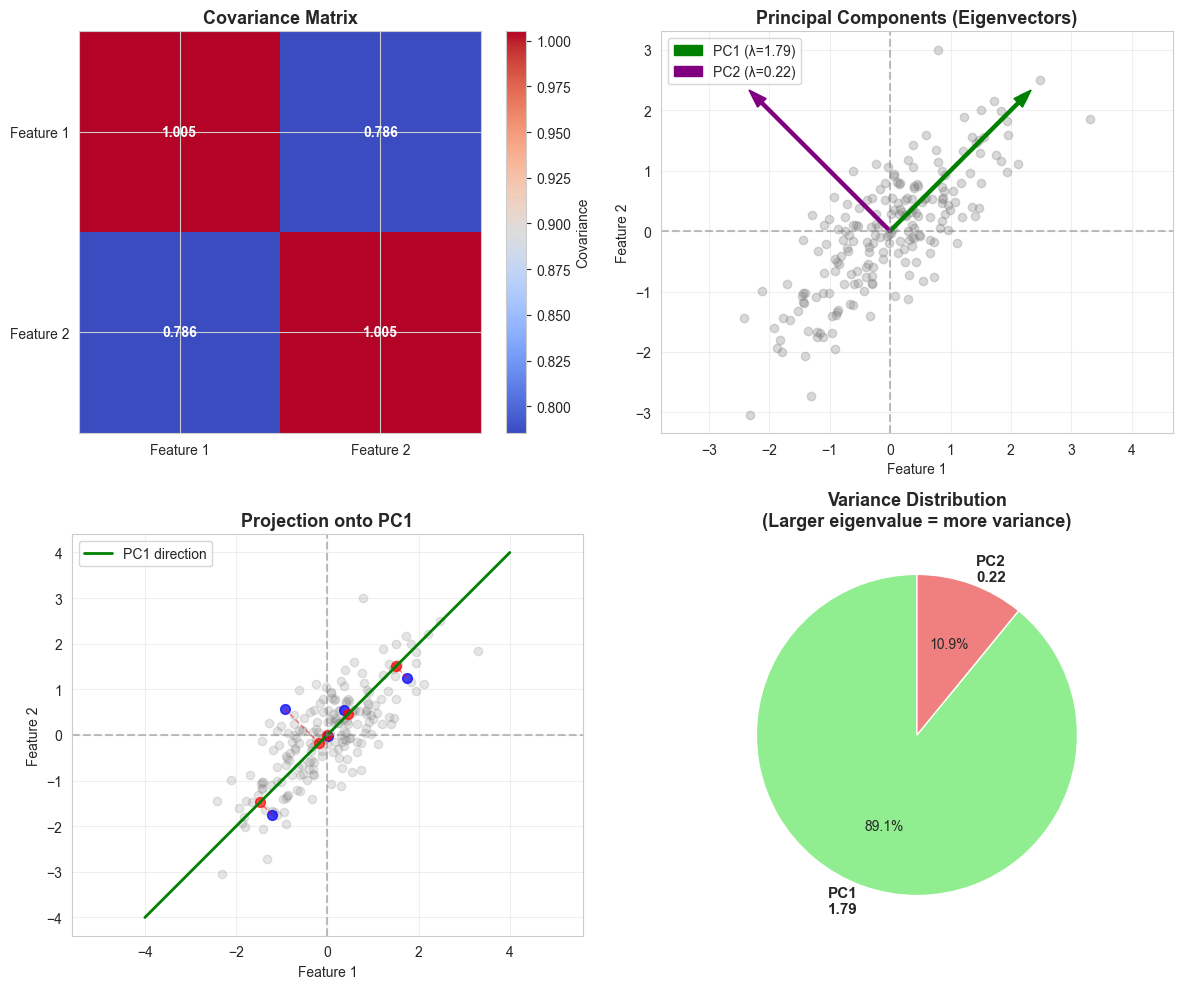

In [24]:
# Let's manually compute PCA to understand the math
print("="*60)
print("STEP-BY-STEP PCA CALCULATION")
print("="*60)

# Step 1: Standardization (already done)
print("\n1. Standardized data (first 5 points):")
print(X_scaled[:5])

# Step 2: Compute covariance matrix
cov_matrix = np.cov(X_scaled.T)
print("\n2. Covariance matrix:")
print(cov_matrix)

# Step 3: Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("\n3. Eigenvalues (variance):")
print(f"  λ1: {eigenvalues[0]:.4f}")
print(f"  λ2: {eigenvalues[1]:.4f}")

print("\n4. Eigenvectors (principal components):")
print(f"  v1 (PC1): {eigenvectors[:, 0]}")
print(f"  v2 (PC2): {eigenvectors[:, 1]}")

# Step 4: Sort by eigenvalues (descending)
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

print("\n5. Sorted (descending by eigenvalue):")
print(f"  λ1: {sorted_eigenvalues[0]:.4f}, v1: {sorted_eigenvectors[:, 0]}")
print(f"  λ2: {sorted_eigenvalues[1]:.4f}, v2: {sorted_eigenvectors[:, 1]}")

# Step 5: Project data onto principal components
manual_pca = X_scaled @ sorted_eigenvectors
print("\n6. Manual PCA projection (first 5 points):")
print(manual_pca[:5])

# Compare with sklearn's PCA
print("\n7. Compare with sklearn PCA (first 5 points):")
print(X_pca[:5])

print("\n8. Explained variance ratio:")
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
print(f"  PC1: {explained_variance_ratio[0]:.2%}")
print(f"  PC2: {explained_variance_ratio[1]:.2%}")

# Visualize the math
plt.figure(figsize=(12, 10))

# Plot 1: Covariance matrix visualization
plt.subplot(2, 2, 1)
plt.imshow(cov_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Covariance')
plt.xticks([0, 1], ['Feature 1', 'Feature 2'])
plt.yticks([0, 1], ['Feature 1', 'Feature 2'])
plt.title('Covariance Matrix', fontsize=13, fontweight='bold')

# Add values in cells
for i in range(2):
    for j in range(2):
        plt.text(j, i, f'{cov_matrix[i, j]:.3f}', ha='center', va='center', 
                 color='white' if abs(cov_matrix[i, j]) > 0.5 else 'black', fontweight='bold')

# Plot 2: Eigenvectors visualization
plt.subplot(2, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.3, color='gray')

# Plot eigenvectors
origin = [0, 0]
for i, (vec, val) in enumerate(zip(sorted_eigenvectors.T, sorted_eigenvalues)):
    color = 'green' if i == 0 else 'purple'
    label = f'PC{i+1} (λ={val:.2f})'
    plt.arrow(origin[0], origin[1], vec[0]*3, vec[1]*3, 
              color=color, width=0.05, head_width=0.2, label=label)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Principal Components (Eigenvectors)', fontsize=13, fontweight='bold')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.3)

# Plot 3: Projection illustration
plt.subplot(2, 2, 3)
# Plot a few points and their projections
n_points_to_show = 5
sample_indices = np.random.choice(len(X_scaled), n_points_to_show, replace=False)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.2, color='gray')
for idx in sample_indices:
    point = X_scaled[idx]
    
    # Project onto PC1
    projection = (point @ sorted_eigenvectors[:, 0]) * sorted_eigenvectors[:, 0]
    
    # Plot original point and projection
    plt.plot([point[0], projection[0]], [point[1], projection[1]], 'r--', alpha=0.5, linewidth=1)
    plt.scatter(point[0], point[1], color='blue', s=50, alpha=0.7)
    plt.scatter(projection[0], projection[1], color='red', s=50, alpha=0.7)

# Plot PC1 line
pc1_line = np.array([[-4, 4], [-4*sorted_eigenvectors[1, 0]/sorted_eigenvectors[0, 0], 
                              4*sorted_eigenvectors[1, 0]/sorted_eigenvectors[0, 0]]])
plt.plot(pc1_line[0], pc1_line[1], 'g-', linewidth=2, label='PC1 direction')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Projection onto PC1', fontsize=13, fontweight='bold')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.3)

# Plot 4: Variance explained
plt.subplot(2, 2, 4)
wedges, texts, autotexts = plt.pie(sorted_eigenvalues, 
                                    labels=[f'PC1\n{sorted_eigenvalues[0]:.2f}', 
                                            f'PC2\n{sorted_eigenvalues[1]:.2f}'],
                                    colors=['lightgreen', 'lightcoral'],
                                    autopct='%1.1f%%',
                                    startangle=90)
plt.title('Variance Distribution\n(Larger eigenvalue = more variance)', 
          fontsize=13, fontweight='bold')

# Make labels bold
for text in texts:
    text.set_fontweight('bold')
    text.set_fontsize(11)

plt.tight_layout()
plt.savefig('5_pca_math_visualized.png', dpi=100, bbox_inches='tight')
plt.show()


DEMONSTRATING DIFFERENT PCA SCENARIOS

1. PCA with 2 components (keeps all information):


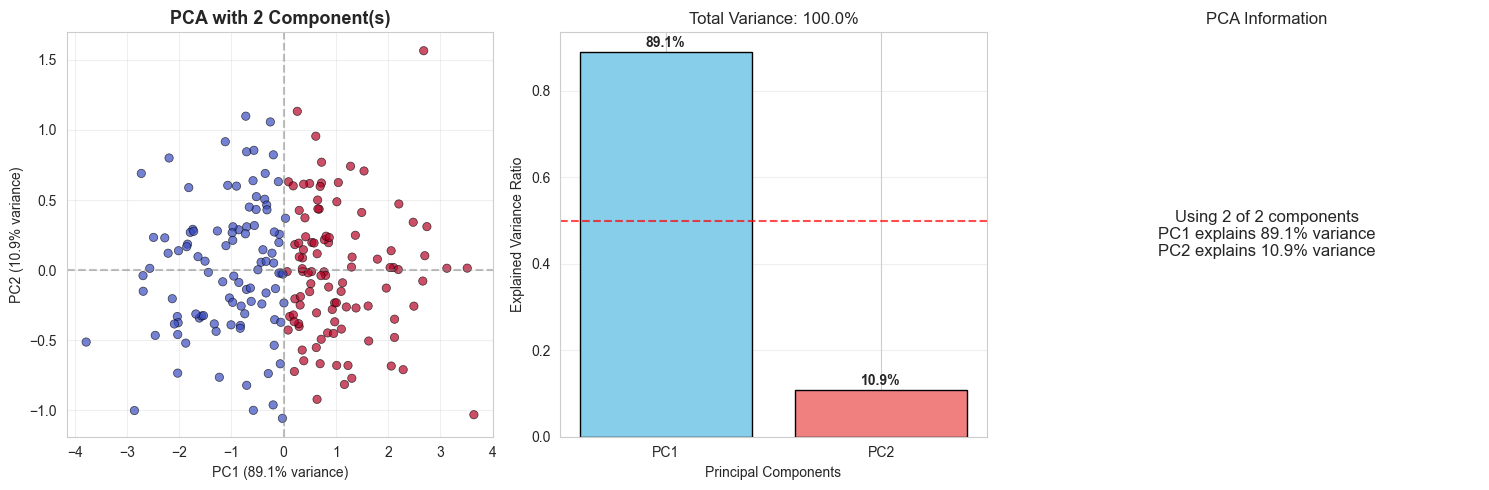


2. PCA with 1 component (dimensionality reduction):


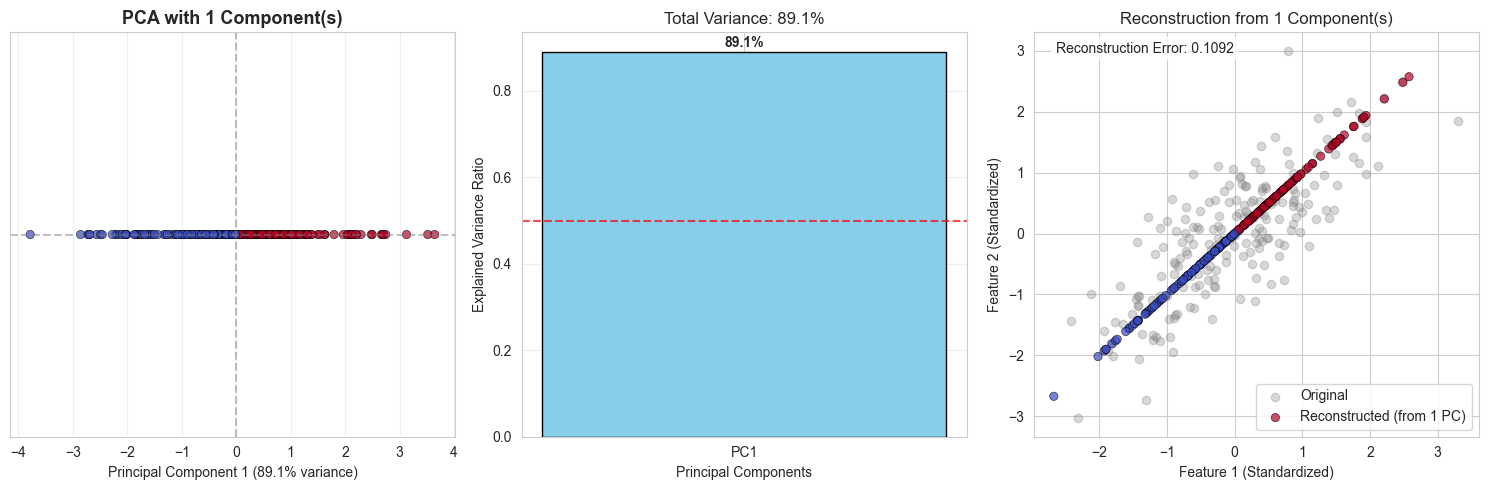


3. PCA with 1 component and reconstruction:


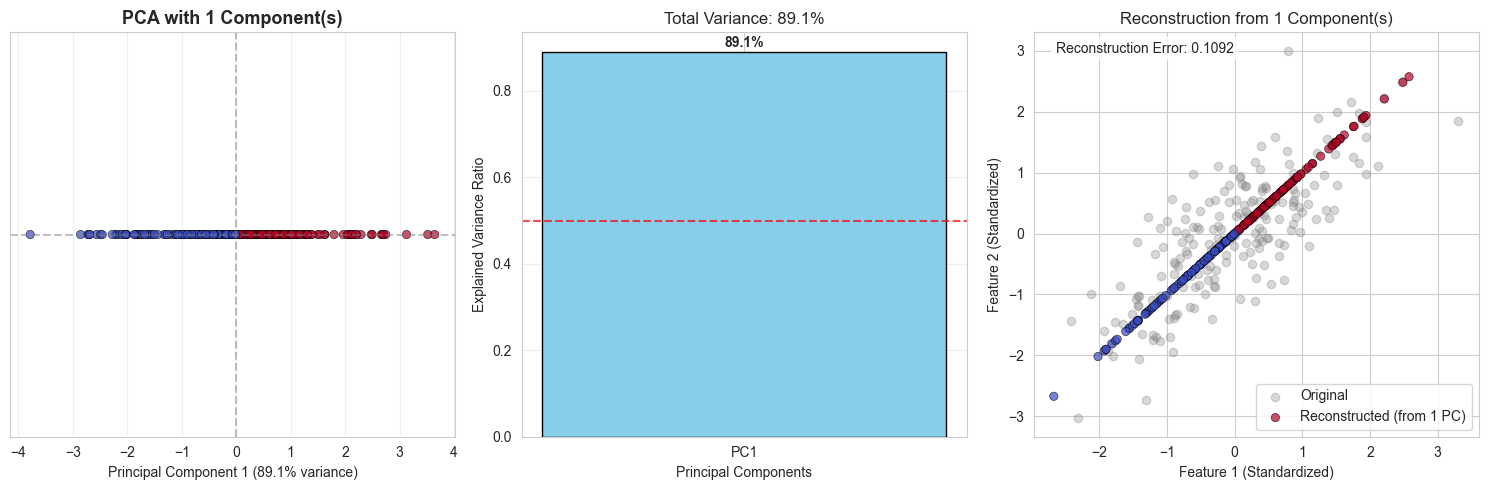

In [25]:
# Function to visualize PCA with different parameters
def visualize_pca_effects(n_components=2, show_reconstruction=False):
    """
    Interactive visualization of PCA with different parameters
    """
    fig = plt.figure(figsize=(15, 5))
    
    # Apply PCA with specified number of components
    pca_temp = PCA(n_components=n_components)
    X_pca_temp = pca_temp.fit_transform(X_scaled)
    
    # Subplot 1: PCA transformed data
    plt.subplot(1, 3, 1)
    if n_components == 1:
        plt.scatter(X_pca_temp, np.zeros_like(X_pca_temp), c=y, cmap='coolwarm', 
                   alpha=0.7, edgecolors='black', linewidth=0.5)
        plt.xlabel(f'Principal Component 1 ({pca_temp.explained_variance_ratio_[0]:.1%} variance)')
        plt.yticks([])
    else:
        plt.scatter(X_pca_temp[:, 0], X_pca_temp[:, 1], c=y, cmap='coolwarm', 
                   alpha=0.7, edgecolors='black', linewidth=0.5)
        plt.xlabel(f'PC1 ({pca_temp.explained_variance_ratio_[0]:.1%} variance)')
        plt.ylabel(f'PC2 ({pca_temp.explained_variance_ratio_[1]:.1%} variance)')
    
    plt.title(f'PCA with {n_components} Component(s)', fontsize=13, fontweight='bold')
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: Explained variance
    plt.subplot(1, 3, 2)
    if n_components == 2:
        plt.bar(['PC1', 'PC2'], pca_temp.explained_variance_ratio_, 
                color=['skyblue', 'lightcoral'], edgecolor='black')
        total_variance = sum(pca_temp.explained_variance_ratio_)
    else:
        plt.bar(['PC1'], [pca_temp.explained_variance_ratio_[0]], 
                color='skyblue', edgecolor='black')
        total_variance = pca_temp.explained_variance_ratio_[0]
    
    plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7)
    plt.xlabel('Principal Components')
    plt.ylabel('Explained Variance Ratio')
    plt.title(f'Total Variance: {total_variance:.1%}')
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add values on bars
    if n_components == 2:
        for i, v in enumerate(pca_temp.explained_variance_ratio_):
            plt.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
    else:
        plt.text(0, pca_temp.explained_variance_ratio_[0] + 0.01, 
                f'{pca_temp.explained_variance_ratio_[0]:.1%}', ha='center', fontweight='bold')
    
    # Subplot 3: Reconstruction (if showing)
    plt.subplot(1, 3, 3)
    if show_reconstruction and n_components < 2:
        # Reconstruct data from PCA components
        X_reconstructed = pca_temp.inverse_transform(X_pca_temp)
        
        plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.3, color='gray', label='Original')
        plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], c=y, cmap='coolwarm', 
                   alpha=0.7, edgecolors='black', linewidth=0.5, label=f'Reconstructed (from {n_components} PC)')
        
        plt.xlabel('Feature 1 (Standardized)')
        plt.ylabel('Feature 2 (Standardized)')
        plt.title(f'Reconstruction from {n_components} Component(s)')
        plt.legend()
        
        # Calculate reconstruction error
        reconstruction_error = np.mean((X_scaled - X_reconstructed) ** 2)
        plt.annotate(f'Reconstruction Error: {reconstruction_error:.4f}', 
                    xy=(0.05, 0.95), xycoords='axes fraction',
                    fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    else:
        # Show information about the components
        plt.text(0.5, 0.5, f'Using {n_components} of 2 components\n' +
                f'PC1 explains {pca_temp.explained_variance_ratio_[0]:.1%} variance\n' +
                (f'PC2 explains {pca_temp.explained_variance_ratio_[1]:.1%} variance' 
                 if n_components == 2 else ''),
                ha='center', va='center', fontsize=12, transform=plt.gca().transAxes)
        plt.title(f'PCA Information')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Demonstrate different PCA scenarios
print("\n" + "="*60)
print("DEMONSTRATING DIFFERENT PCA SCENARIOS")
print("="*60)

print("\n1. PCA with 2 components (keeps all information):")
visualize_pca_effects(n_components=2)

print("\n2. PCA with 1 component (dimensionality reduction):")
visualize_pca_effects(n_components=1, show_reconstruction=True)

print("\n3. PCA with 1 component and reconstruction:")
visualize_pca_effects(n_components=1, show_reconstruction=True)

In [31]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



